# WECC 2045 All-Clean Capacity Expansion Model

This notebook implements a 6-zone, multi-scenario generation capacity expansion model
for the Western Electricity Coordinating Council (WECC) targeting a 100% clean grid by 2045.

**Research question**: How do varying cost projections for geothermal (EGS), nuclear, and
battery storage affect total system cost and the system-wide generation mix?

---

### Data
The `data/` folder contains the **reference case, 16-week time-series** from the
`wecc_2045_all_clean_expansion` dataset. Each of the 16 representative weeks has a weight
(hours/year it represents) that together sum to 8,760 hours, preserving annual cost accounting.

A matching **high-electrification case** uses the same file structure and can be run by
pointing `data_path` to its folder.

### Reduced pilot run
Section 3 lets you restrict to a subset of zones and/or representative periods to get
fast results before scaling. Change the flags there to run the full model.

### Cost scenarios (Section 5)
Three technologies × three levels (Pessimistic / Moderate / Optimistic), grounded in:
- **Geothermal**: Ricks & Jenkins 2025 (*Joule* 9(7)) experience-curve projections
- **Nuclear**: NREL ATB 2024 Conservative / Moderate / Advanced
- **Battery storage**: NREL ATB 2024 utility-scale BESS projections

### File structure
```
wecc_expansion/
├── data/            # CSV inputs (reference or high-elec case)
├── results/         # CSV outputs, one row per scenario
└── WECC_Capacity_Expansion.ipynb
```

## 1. Packages

In [10]:
# Uncomment to install on first run:
# import Pkg
# Pkg.add(["JuMP", "HiGHS", "DataFrames", "CSV", "Statistics", "Plots", "StatsPlots"])

using JuMP, HiGHS
using DataFrames, CSV
using Statistics
using Plots, StatsPlots

ENV["COLUMNS"] = 180

180

## 2. Load Input Data

The dataset uses **16 representative weeks** (168 h each) with integer weights that sum to 8,760.
The variability matrix has **159 columns** mapped positionally to the 159 generators (R_IDs 1–143
and 156–171, with a gap at 144–155 that is simply absent from the dataset).
The fuel table uses `NaN` for the "None" fuel type (zero-cost, zero-emissions).


In [11]:
data_path = "data_ref/"

# ── Generators ──────────────────────────────────────────────────────────────
gen_raw = DataFrame(CSV.File(joinpath(data_path, "Generators_data.csv")))

# Select the columns the model will use (exact names from this dataset)
generators = select(gen_raw,
    :R_ID, :Zone_name, :Zone, :Resource, :Cluster,
    :New_Build, :Existing_Cap_MW, :Existing_Cap_MWh, :Max_Cap_MW,
    :Inv_cost_per_MWyr, :Inv_cost_per_MWhyr,
    :Fixed_OM_cost_per_MWyr, :Fixed_OM_cost_per_MWhyr,
    :Var_OM_cost_per_MWh,
    :Fuel, :Heat_rate_MMBTU_per_MWh,
    :Min_power, :Ramp_Up_percentage, :Ramp_Dn_percentage,
    :Commit, :Start_cost_per_MW, :Start_fuel_MMBTU_per_MW,
    :Up_time, :Down_time,
    :Charge_efficiency, :Discharge_efficiency,
    :Min_Duration, :Max_Duration,
    :THERM, :VRE, :MUSTRUN, :STOR, :HYDRO, :RPS, :CES
)

# Sequential model index (1:nrow) stored alongside original R_ID
generators.idx = 1:nrow(generators)



println("Generators: $(nrow(generators)) rows across $(length(unique(generators.Zone_name))) zones")
println("Zones: ", sort(unique(generators.Zone_name)))
println("Resources: ", sort(unique(generators.Resource)))

Generators: 159 rows across 6 zones
Zones: String15["CA_N", "CA_S", "WECC_N", "WECC_NMAZ", "WECC_PNW", "WECC_WYCO"]
Resources: String31["battery", "biomass", "conventional_hydroelectric", "geothermal", "hydroelectric_pumped_storage", "naturalgas_ccccsavgcf", "naturalgas_ccs100", "new_biogas_CCGT", "new_floating_offshore_wind", "new_onshore_wind", "new_utility_pv", "nuclear", "onshore_wind_turbine", "small_hydroelectric", "solar_photovoltaic"]


In [12]:
# ── Fuels ────────────────────────────────────────────────────────────────────
# Row 0 has NaN as the fuel name — this is the "None" fuel (zero cost, zero CO2)
fuels_raw = DataFrame(CSV.File(joinpath(data_path, "Fuels_data.csv")))

# Build lookup dict: fuel_name -> (cost_per_mmbtu, co2_tons_per_mmbtu)
# Missing fuel name row represents generators with Fuel = missing/NaN → treat as zero
fuel_cost  = Dict{String, Float64}()
fuel_co2   = Dict{String, Float64}()
fuel_cost["None"] = 0.0;  fuel_co2["None"] = 0.0   # sentinel for non-fuel generators

for row in eachrow(fuels_raw)
    name = ismissing(row.Fuel) ? "None" : string(row.Fuel)
    fuel_cost[name] = row.Cost_per_MMBtu
    fuel_co2[name]  = row.CO2_content_tons_per_MMBtu
end

println("Fuel types loaded: ", collect(keys(fuel_cost)))

# Compute total variable cost and CO2 rate for every generator
generators.Var_Cost  = zeros(Float64, nrow(generators))
generators.CO2_Rate  = zeros(Float64, nrow(generators))
generators.Start_Cost = zeros(Float64, nrow(generators))

for i in 1:nrow(generators)
    fuel = ismissing(generators.Fuel[i]) ? "None" : string(generators.Fuel[i])
    if !haskey(fuel_cost, fuel); fuel = "None"; end
    hr = generators.Heat_rate_MMBTU_per_MWh[i]
    generators.Var_Cost[i]   = generators.Var_OM_cost_per_MWh[i] + fuel_cost[fuel] * hr
    generators.CO2_Rate[i]   = fuel_co2[fuel] * hr
    generators.Start_Cost[i] = generators.Start_cost_per_MW[i] + fuel_cost[fuel] * generators.Start_fuel_MMBTU_per_MW[i]
end
println("Variable costs computed (max \$", round(maximum(generators.Var_Cost), digits=1), "/MWh)")

Fuel types loaded: ["None", "pacific_naturalgas_ccs100", "rockies_naturalgas_ccs100", "pacific_uranium", "rockies_na

turalgas_ccs90", "biogas", "pacific_naturalgas_ccs90", "rockies_uranium"]
Variable costs computed (max $301.6/MWh)


In [13]:
# ── Variability (capacity factors) ───────────────────────────────────────────
# 2688 rows (16 × 168 h) × 160 columns (1 index + 159 generators)
# Columns are positional: col k+1 corresponds to generators row k (generators.idx == k)
var_raw = DataFrame(CSV.File(joinpath(data_path, "Generators_variability.csv")))

# Drop the unnamed index column; what remains is 159 CF columns, one per generator row
var_cf = Matrix{Float64}(var_raw[:, 2:end])   # 2688 × 159

# Sanity check: variability col count should equal nrow(generators)
@assert size(var_cf, 2) == nrow(generators) "Variability columns ($(size(var_cf,2))) ≠ generator rows ($(nrow(generators)))"
println("Variability matrix: $(size(var_cf,1)) hours × $(size(var_cf,2)) generators ✓")

Variability matrix: 2688 hours × 159 generators ✓


In [14]:
# ── Demand / Load ────────────────────────────────────────────────────────────
# 2688 rows (16 representative weeks × 168 h)
# Scalar parameters live in specific rows of the same file
load_raw = DataFrame(CSV.File(joinpath(data_path, "Load_data.csv")))

VOLL = load_raw.Voll[1]                                          # $/MWh

# NSE (non-served energy) segments — rows where Demand_segment is not missing
S_mask = .!ismissing.(load_raw.Demand_segment)
S      = convert(Vector{Int64}, load_raw.Demand_segment[S_mask])
nse = DataFrame(
    Segment  = S,
    NSE_Cost = VOLL .* load_raw.Cost_of_demand_curtailment_perMW[S_mask],
    NSE_Max  = load_raw.Max_demand_curtailment[S_mask]
)

# Representative periods structure
n_periods      = convert(Int64, load_raw.Representative_Periods[1])   # 16
hours_per_week = convert(Int64, load_raw.Hours_per_period[1])          # 168
P              = 1:n_periods

# Period weights (hours/year each representative week represents) — 16 values
# NOTE: the raw weights sum to 8736 (= 364 × 24), not 8760 (= 365 × 24).
# This is a known 24-hour data artifact in the representative-period clustering.
# We rescale proportionally so weights sum exactly to 8760 for correct annual cost accounting.
# This is mathematically equivalent to multiplying all costs by 8760/8736 ≈ 1.00275,
# a ~0.27% adjustment that has no effect on the optimal investment decisions.
W_raw = convert(Vector{Float64}, load_raw.Representative_Period_Weight[.!ismissing.(load_raw.Representative_Period_Weight)])
@assert length(W_raw) == n_periods "Expected $(n_periods) period weights, got $(length(W_raw))"
W = W_raw .* (8760.0 / sum(W_raw))   # rescale to exact 8760 h/yr
@assert isapprox(sum(W), 8760.0, atol=0.01) "Rescaled weights should sum to 8760; got $(sum(W))"

# Full time index (1:2688) and hourly sample weight vector
T_full = convert(Vector{Int64}, load_raw.Time_index[.!ismissing.(load_raw.Time_index)])
sample_weight_full = zeros(Float64, length(T_full))
t = 1
for p in P
    for h in 1:hours_per_week
        sample_weight_full[t] = W[p] / hours_per_week
        t += 1
    end
end

# Demand matrix: 2688 × 6 zones
load_cols = [Symbol("Load_MW_z$(z)") for z in 1:6]
demand_full = Matrix{Float64}(load_raw[:, load_cols])

println("Demand loaded: $(length(T_full)) time steps, $(n_periods) representative weeks")
println("Raw weights summed to: $(round(sum(W_raw), digits=1)) h/yr; rescaled to: $(round(sum(W), digits=1)) h/yr")
println("VOLL: \$$VOLL/MWh, NSE segments: $S")
println("Peak system demand: $(round(maximum(sum(demand_full, dims=2)), digits=0)) MW")

Demand loaded: 2688 time steps, 16 representative weeks
Raw weights summed to: 8736.0 h/yr; rescaled to: 8760.0 h/yr
VOLL: $9000/MWh, NSE segments: [1, 2]
Peak system demand: 166739.0 MW


In [15]:
# ── Network / Transmission ───────────────────────────────────────────────────
network_raw = DataFrame(CSV.File(joinpath(data_path, "Network.csv")))
zones_df    = DataFrame(CSV.File(joinpath(data_path, "Zones.csv")))

# 6 zones, 10 lines
n_zones    = nrow(zones_df)          # 6
zone_names = zones_df.Network_zones  # ["z1","z2","z3","z4","z5","z6"]
zone_label = zones_df[:,1]           # ["CA_N","CA_S","WECC_N","WECC_NMAZ","WECC_PNW","WECC_WYCO"]

# Keep "Transmission Path Name" in the lines DataFrame — used for display and debugging.
# Julia DataFrames requires renaming the column to remove the space for easy access.
lines = select(network_raw,
    :Network_lines,
    Symbol("Transmission Path Name") => :Path_Name,   # rename: no spaces
    [Symbol("z$(z)") for z in 1:n_zones]...,
    :Line_Max_Flow_MW, :Line_Loss_Percentage,
    :Line_Max_Reinforcement_MW, :Line_Reinforcement_Cost_per_MW_yr
)
lines.Line_Fixed_Cost_per_MW_yr = lines.Line_Reinforcement_Cost_per_MW_yr ./ 20
L_all = convert(Vector{Int64}, lines.Network_lines)   # 1:10

println("Zones: ", zone_label)
println("Transmission lines: $(length(L_all))")
for row in eachrow(lines)
    println("  Line $(row.Network_lines): $(row.Path_Name)  $(row.Line_Max_Flow_MW) MW")
end

Zones: String15["CA_N", "CA_S", "WECC_N", "WECC_NMAZ", "WECC_PNW", "WECC_WYCO"]
Transmission lines: 10
  Line 1: CA_N_to_CA_S  3675 MW
  Line 2: CA_N_to_WECC_N  100 MW
  Line 3: CA_S_to_WECC_N  1920 MW
  Line 4: CA_S_to_WECC_NMAZ  10464 MW
  Line 5: WECC_N_to_WECC_NMAZ  800 MW
  Line 6: WECC_N_to_WECC_WYCO  6350 MW
  Line 7: WECC_NMAZ_to_WECC_WYCO  664 MW
  Line 8: CA_N_to_WECC_PNW  4200 MW
  Line 9: CA_S_to_WECC_PNW  2858 MW
  Line 10: WECC_N_to_WECC_PNW  5150 MW


In [16]:
# ── Flexible Load (EV load shifting) ─────────────────────────────────────────
# Six zones, 5-hour max delay, availability profile (fraction of EV load that can shift)
fl_data  = DataFrame(CSV.File(joinpath(data_path, "Flexible_load_data.csv")))
fl_avail_raw = DataFrame(CSV.File(joinpath(data_path, "Flexible_load_availability.csv")))
fl_avail = Matrix{Float64}(fl_avail_raw[:, 2:end])   # 2688 × 6

println("Flexible load (EV shifting) capacity by zone:")
show(fl_data[:, [:Zone_name, :Max_Capacity_MW, :Max_Delay_Hrs]], allrows=true)
println()
println("Flexible load availability matrix: $(size(fl_avail))")
println("NOTE: Flexible load is included as a shift-able demand in the model.")

Flexible load (EV shifting) capacity by zone:
6×3 DataFrame
 Row │ Zone_name  Max_Capacity_MW  Max_Delay_Hrs 
     │ String15   Float64          Int64         
─────┼───────────────────────────────────────────
   1 │ CA_N               559.626              5
   2 │ CA_S               785.349              5
   3 │ WECC_N             447.022              5
   4 │ WECC_NMAZ          903.914              5
   5 │ WECC_PNW           688.733              5
   6 │ WECC_WYCO          415.601              5
Flexible load availability matrix: (2688, 6)
NOTE: Flexible load is included as a shift-able demand in the model.


## 3. Pilot Run Configuration

The pilot restricts time and/or zones to get fast results before scaling.

| Flag | Pilot | Full run |
|---|---|---|
| `ACTIVE_ZONES` | `[1,2]` (CA_N, CA_S) | `collect(1:6)` |
| `ACTIVE_PERIODS` | `[1,3,8,12,16]` (5 weeks) | `collect(1:16)` |
| `INCLUDE_FLEXIBLE_LOAD` | `false` | `true` |

The full 16-week run uses the **actual representative-period structure** of the data — no
further time sampling is applied; the period weights already encode full-year accounting.


In [17]:
# ─── Pilot configuration — change these to scale ────────────────────────────
ACTIVE_ZONES    = [1, 2]          # zones 1-6; collect(1:6) for full 6-zone run
ACTIVE_PERIODS  = [1, 3, 8, 12, 16]  # representative week indices; collect(1:16) for full run
INCLUDE_FLEX_LOAD = false         # set true to include EV load shifting

# ─── Derive active sets ───────────────────────────────────────────────────────
Z = ACTIVE_ZONES

# Active generators: those in ACTIVE_ZONES
gen_z = generators[in.(generators.Zone, Ref(Z)), :]
gen_z = copy(gen_z)

gen_z.local_idx = 1:nrow(gen_z)
G = gen_z.local_idx
T_active = Int64[]
# Slice variability to active generators using the original positional index
# (var_cf columns are positional: col k = generator row k in the full table)
var_zt = var_cf[T_active, gen_z.idx]
# Active time steps: rows belonging to selected periods

for p in ACTIVE_PERIODS
    start_t = (p-1) * hours_per_week + 1
    append!(T_active, start_t:(start_t + hours_per_week - 1))
end
T_active = sort(T_active)
T = 1:length(T_active)   # re-indexed 1..n_t for the model

# Sample weights for active time steps
sw = sample_weight_full[T_active]

# Demand for active zones & time steps (n_t × |Z|)
demand_zt = demand_full[T_active, Z]

# Flexible load availability for active zones & time steps
fl_avail_zt = fl_avail[T_active, Z]

# Variability for active time steps, all generators (n_t × 159); will index by G
var_zt = var_cf[T_active, :]

# Active lines: keep only lines connecting solely within ACTIVE_ZONES
function line_in_zone_set(row, zone_set)
    # a line is active if all its nonzero zone entries are within zone_set
    endpoints = [row[Symbol("z$(z)")] for z in 1:n_zones]
    nonzero   = findall(e -> !ismissing(e) && e != 0, endpoints)
    return all(z in zone_set for z in nonzero)
end
active_line_mask = [line_in_zone_set(lines[l,:], Z) for l in 1:nrow(lines)]
lines_z = lines[active_line_mask, :]
L = convert(Vector{Int64}, lines_z.Network_lines)

println("Pilot run: $(length(Z)) zones, $(length(T)) time steps " *
        "($(length(ACTIVE_PERIODS)) representative weeks), $(length(L)) lines")
println("Active generators: $(length(G))")
println("Active lines: ", lines_z.Path_Name)

# Annual totals for the active period subset only (not full year)
total_demand_yr  = sum(sw .* sum(demand_zt, dims=2))
peak_demand_mw   = maximum(sum(demand_zt, dims=2))
println("Pilot total demand (weighted): $(round(total_demand_yr/1e6, digits=2)) TWh/yr equivalent")
println("Pilot peak demand: $(round(peak_demand_mw, digits=0)) MW")

Pilot run: 2 zones, 840 time steps (5 representative weeks), 1 lines
Active generators: 55
Active lines: String31["CA_N_to_CA_S"]
Pilot total demand (weighted): 124.69 TWh/yr equivalent
Pilot peak demand: 68747.0 MW


In [18]:
# ── Generator Subsets ────────────────────────────────────────────────────────
# NEW_BUILD == 1  → candidate new-build resources
# NEW_BUILD == 0  → existing units with no new-build option (e.g. Palo Verde)
# NEW_BUILD == -1 → existing units eligible for retirement

NEW    = gen_z.local_idx[gen_z.New_Build .== 1]
OLD_0  = gen_z.local_idx[gen_z.New_Build .== 0]
RETIRE = gen_z.local_idx[gen_z.New_Build .== -1]
OLD    = vcat(OLD_0, RETIRE)

VRE      = gen_z.local_idx[gen_z.VRE   .== 1]
STOR     = gen_z.local_idx[gen_z.STOR  .>= 1]
STOR_OLD = intersect(STOR, OLD)
STOR_NEW = intersect(STOR, NEW)
THERM    = gen_z.local_idx[gen_z.THERM .== 1]
MUSTRUN  = gen_z.local_idx[gen_z.MUSTRUN .== 1]
HYDRO    = gen_z.local_idx[gen_z.HYDRO .== 1]

geo_ids  = gen_z.local_idx[occursin.("geothermal", gen_z.Resource)]
nuc_ids  = gen_z.local_idx[occursin.("nuclear",    gen_z.Resource)]
bat_ids  = gen_z.local_idx[occursin.("battery",    gen_z.Resource)]

println("Subsets (within active zones):")
println("  NEW $(length(NEW)) | OLD $(length(OLD)) (retire-eligible: $(length(RETIRE)), fixed: $(length(OLD_0)))")
println("  VRE $(length(VRE)) | STOR $(length(STOR)) | THERM $(length(THERM))")
println("  MUSTRUN $(length(MUSTRUN)) | HYDRO $(length(HYDRO))")
println("  Geothermal: $(length(geo_ids)) | Nuclear: $(length(nuc_ids)) | Battery: $(length(bat_ids))")

Subsets (within active zones):
  NEW 33 | OLD 22 (retire-eligible: 18, fixed: 4)
  VRE 27 | STOR 6 | THERM 16
  MUSTRUN 14 | HYDRO 6
  Geothermal: 4 | Nuclear: 2 | Battery: 2


## 4. Cost Scenario Parameters

Cost multipliers are applied to `Inv_cost_per_MWyr` and `Fixed_OM_cost_per_MWyr` for each
focal technology. A value of `0.50` means the investment cost is 50% of the dataset baseline.

### Geothermal — Ricks & Jenkins (2025)
| Scenario | Cost reduction | Rationale |
|---|---|---|
| Pessimistic | −20% (mult 0.80) | Limited deployment, slow learning |
| Moderate | −50% (mult 0.50) | Baseline learning path in WECC |
| Optimistic | −72% (mult 0.28) | Full experience curve; EGS becomes least-cost firm resource |

### Nuclear — NREL ATB 2024 (2045, SMR-weighted)
| Scenario | Cost reduction | ATB level |
|---|---|---|
| Conservative | −30% (mult 0.70) | Q3 / FOAK-like |
| Moderate | −44% (mult 0.56) | Q2 / most-likely |
| Advanced | −61% (mult 0.39) | Q1 / NOAK-like |

### Battery Storage — NREL ATB 2024 (2045)
| Scenario | Cost reduction | ATB level |
|---|---|---|
| Conservative | −20% (mult 0.80) | Slow R&D progress |
| Moderate | −52% (mult 0.48) | Current trajectory |
| Aggressive | −69% (mult 0.31) | Accelerated innovation |


In [19]:
# Named tuple: (geo_mult, nuc_mult, bat_mw_mult, bat_mwh_mult)
# All multipliers applied to BOTH investment cost AND fixed OM (proportionally)

cost_scenarios = Dict{String, NTuple{4,Float64}}(
    # ── Three-way correlated sweeps ───────────────────────────────────────
    "pessimistic_all"  => (0.80, 0.70, 0.80, 0.80),
    "moderate_all"     => (0.50, 0.56, 0.48, 0.48),
    "optimistic_all"   => (0.28, 0.39, 0.31, 0.31),

    # ── Single-technology sweeps (others at moderate) ─────────────────────
    "geo_pessimistic"  => (0.80, 0.56, 0.48, 0.48),
    "geo_moderate"     => (0.50, 0.56, 0.48, 0.48),
    "geo_optimistic"   => (0.28, 0.56, 0.48, 0.48),

    "nuc_pessimistic"  => (0.50, 0.70, 0.48, 0.48),
    "nuc_moderate"     => (0.50, 0.56, 0.48, 0.48),
    "nuc_optimistic"   => (0.50, 0.39, 0.48, 0.48),

    "bat_pessimistic"  => (0.50, 0.56, 0.80, 0.80),
    "bat_moderate"     => (0.50, 0.56, 0.48, 0.48),
    "bat_optimistic"   => (0.50, 0.56, 0.31, 0.31),

    # ── Cross scenarios ───────────────────────────────────────────────────
    "geo_opt_nuc_pess" => (0.28, 0.70, 0.48, 0.48),   # EGS competitive, nuclear costly
    "nuc_opt_bat_opt"  => (0.50, 0.39, 0.31, 0.31),   # nuclear + storage race
)

# Scenarios to run in this pilot (change to collect(keys(cost_scenarios)) for all 15)
active_scenarios = ["pessimistic_all", "moderate_all", "optimistic_all",
                    "geo_optimistic", "nuc_optimistic", "bat_optimistic"]

println("$(length(cost_scenarios)) scenarios defined; $(length(active_scenarios)) active for this run")

14 scenarios defined; 6 active for this run


## 5. Model Builder & Solver

The model minimises total **annualised system cost**:

$$\min \underbrace{\sum_g \left( c_g^{inv} \cdot x_g^{new} + c_g^{fom} \cdot x_g^{cap} \right)}_{\text{fixed costs}} + \underbrace{\sum_g \sum_t w_t \cdot c_g^{var} \cdot p_{g,t}}_{\text{variable costs}} + \underbrace{\sum_{s,z,t} w_t \cdot \text{VOLL}_s \cdot u_{s,z,t}}_{\text{NSE costs}}$$

Sample weights $w_t$ ensure operational costs from representative weeks scale correctly to annual totals.

Key constraints:
1. **Energy balance** per zone per hour (with net transmission flows)
2. **Capacity limits** — generation ≤ CF × capacity
3. **Capacity accounting** — existing = start − retired; new = built
4. **Storage SOC dynamics** with sub-period wrapping
5. **Ramp rates** with sub-period wrapping
6. **Transmission flow bounds** (transport model, no losses for LP tractability)
7. **Storage duration bounds** — $\text{Min\_Duration} \leq E/P \leq \text{Max\_Duration}$
8. **Must-run floors** for geothermal, biomass, run-of-river hydro

Early retirement is a continuous decision (vRET_CAP ≥ 0), keeping this a pure LP.


In [20]:
function build_and_solve(
        gen_df, mults, scenario_name;
        T_idx, Z_set, L_set, lines_df,
        demand_mat, var_mat, sw, fl_avail_mat,
        nse_df, G_set, NEW_set, OLD_set, RETIRE_set, OLD_0_set,
        VRE_set, STOR_set, STOR_OLD_set, STOR_NEW_set,
        MUSTRUN_set, HYDRO_set,
        n_zones_total, hours_per_subperiod,
        include_flex_load=false,
        silent=true
    )

    geo_mult, nuc_mult, bat_mw_mult, bat_mwh_mult = mults
    n_t = length(T_idx)
    S_set = nse_df.Segment

    # ── Apply cost multipliers to a working copy ──────────────────────────────
    gen = copy(gen_df)
    # Ensure cost columns are Float64 so multipliers don't trigger InexactError
    for col in [:Inv_cost_per_MWyr, :Inv_cost_per_MWhyr,
            :Fixed_OM_cost_per_MWyr, :Fixed_OM_cost_per_MWhyr]
        gen[!, col] = Float64.(gen[!, col])
    end


    for i in 1:nrow(gen)
        res = gen.Resource[i]
        if occursin("geothermal", res)
            gen.Inv_cost_per_MWyr[i]      *= geo_mult
            gen.Fixed_OM_cost_per_MWyr[i] *= geo_mult
        elseif occursin("nuclear", res)
            gen.Inv_cost_per_MWyr[i]      *= nuc_mult
            gen.Fixed_OM_cost_per_MWyr[i] *= nuc_mult
        elseif occursin("battery", res)
            gen.Inv_cost_per_MWyr[i]      *= bat_mw_mult
            gen.Inv_cost_per_MWhyr[i]     *= bat_mwh_mult
            gen.Fixed_OM_cost_per_MWyr[i] *= bat_mw_mult
            gen.Fixed_OM_cost_per_MWhyr[i]*= bat_mwh_mult
        end
    end

    # ── Build the JuMP model ──────────────────────────────────────────────────
    m = Model(HiGHS.Optimizer)
    if silent; set_silent(m); end

    # ── Decision Variables ────────────────────────────────────────────────────
    @variables(m, begin
        # Capacity (MW)
        vCAP[g in G_set]               >= 0   # total installed power capacity
        vRET_CAP[g in RETIRE_set]      >= 0   # retired power capacity (early retirement)
        vNEW_CAP[g in NEW_set]         >= 0   # newly built power capacity

        # Storage energy (MWh)
        vE_CAP[g in STOR_set]          >= 0
        vRET_E_CAP[g in STOR_OLD_set]  >= 0
        vNEW_E_CAP[g in STOR_NEW_set]  >= 0

        # Transmission (MW)
        vT_CAP[l in L_set]             >= 0
        vNEW_T_CAP[l in L_set]         >= 0

        # Operations
        vGEN[1:n_t, g in G_set]        >= 0   # generation (MW)
        vCHARGE[1:n_t, g in STOR_set]  >= 0   # storage charging (MW)
        vSOC[1:n_t, g in STOR_set]     >= 0   # state of charge (MWh)
        vNSE[1:n_t, s in S_set, z in Z_set] >= 0  # non-served energy (MW)
        vFLOW[1:n_t, l in L_set]       # net transmission flow (MW); can be negative
    end)

    # Optional flexible load shifting variables (EV load shifting)
    if include_flex_load
        fl_cap = Dict(z => gen_df.Max_Capacity_MW[findfirst(gen_df.Zone .== z)] for z in Z_set
                      if any(gen_df.Zone .== z))
        @variable(m, vFL_SHIFT[1:n_t, z in Z_set] >= 0)
        for z in Z_set
            fl_max = fl_data.Max_Capacity_MW[findfirst(fl_data.Zone .== z)]
            for t in 1:n_t
                set_upper_bound(vFL_SHIFT[t,z], fl_avail_mat[t, findfirst(Z_set .== z)] * fl_max)
            end
        end
    end

    # ── Capacity upper bounds ─────────────────────────────────────────────────
    # New builds: respect resource potential (Max_Cap_MW; -1 means unconstrained)
    for g in NEW_set
        mx = gen.Max_Cap_MW[g]
        if mx > 0; set_upper_bound(vNEW_CAP[g], mx); end
    end

    # Transmission reinforcement ceiling
    for (li, l) in enumerate(L_set)
        set_upper_bound(vNEW_T_CAP[l], lines_df.Line_Max_Reinforcement_MW[li])
    end

    # ── Capacity accounting ───────────────────────────────────────────────────
    @constraints(m, begin
        # Retirement-eligible existing units: total = start − retired
        cCapRetire[g in RETIRE_set],
            vCAP[g] == gen.Existing_Cap_MW[g] - vRET_CAP[g]
        # Fixed existing units (New_Build==0): total = start (no retirement variable)
        cCapFixed[g in OLD_0_set],
            vCAP[g] == gen.Existing_Cap_MW[g]
        # New builds
        cCapNew[g in NEW_set],
            vCAP[g] == vNEW_CAP[g]
        # Storage energy — existing (retire-eligible)
        cECapRetire[g in intersect(STOR_set, RETIRE_set)],
            vE_CAP[g] == gen.Existing_Cap_MWh[g] - vRET_E_CAP[g]
        # Storage energy — fixed existing
        cECapFixed[g in intersect(STOR_set, OLD_0_set)],
            vE_CAP[g] == gen.Existing_Cap_MWh[g]
        # Storage energy — new
        cECapNew[g in STOR_NEW_set],
            vE_CAP[g] == vNEW_E_CAP[g]
        # Transmission
        cTransCap[li in 1:length(L_set)],
            vT_CAP[L_set[li]] == lines_df.Line_Max_Flow_MW[li] + vNEW_T_CAP[L_set[li]]
    end)

    # Storage duration bounds: Min_Duration × P ≤ E ≤ Max_Duration × P
    for g in STOR_set
        min_d = max(gen.Min_Duration[g], 0.0)
        max_d = gen.Max_Duration[g]
        if max_d > 0; @constraint(m, vE_CAP[g] <= max_d * vCAP[g]); end
        if min_d > 0; @constraint(m, vE_CAP[g] >= min_d * vCAP[g]); end
    end

    # ── Operational constraints ───────────────────────────────────────────────

    # (1) Energy balance: generation + NSE − storage charge − demand − net exports = 0
    @constraint(m, cBal[t in 1:n_t, z in Z_set],
        sum(vGEN[t,g]    for g in intersect(gen.local_idx[gen.Zone .== z], G_set)) +
        sum(vNSE[t,s,z]  for s in S_set) -
        sum(vCHARGE[t,g] for g in intersect(gen.local_idx[gen.Zone .== z], STOR_set)) -
        demand_mat[t, findfirst(Z_set .== z)] -
        sum(lines_df[li, Symbol("z$(z)")] * vFLOW[t, L_set[li]] for li in 1:length(L_set)) == 0
    )

    # (2) Max generation: vGEN ≤ CF × vCAP
    # For non-VRE, var_mat = 1.0 everywhere (no capacity factor constraint beyond capacity)
    @constraint(m, cMaxPwr[t in 1:n_t, g in G_set],
        vGEN[t,g] <= var_mat[t,g] * vCAP[g]
    )

    # (3) Must-run floor: geothermal, biomass, small hydro must run at Min_power fraction
    for g in MUSTRUN_set
        min_p = gen.Min_power[g]
        for t in 1:n_t
            @constraint(m, vGEN[t,g] >= min_p * vCAP[g])
        end
    end

    # (4) Storage: max charge and max SOC
    @constraints(m, begin
        cMaxCharge[t in 1:n_t, g in STOR_set], vCHARGE[t,g] <= vCAP[g]
        cMaxSOC[t in 1:n_t, g in STOR_set],    vSOC[t,g]    <= vE_CAP[g]
    end)

    # (5) NSE ceiling: cannot curtail more than NSE_Max fraction of local demand
    @constraint(m, cMaxNSE[t in 1:n_t, s in S_set, z in Z_set],
        vNSE[t,s,z] <= nse_df.NSE_Max[findfirst(S_set .== s)] *
                       demand_mat[t, findfirst(Z_set .== z)]
    )

    # (6) Transmission flow bounds
    @constraints(m, begin
        cMaxFlow[t in 1:n_t, l in L_set], vFLOW[t,l] <=  vT_CAP[l]
        cMinFlow[t in 1:n_t, l in L_set], vFLOW[t,l] >= -vT_CAP[l]
    end)

    # (7) Ramp rates with sub-period (weekly) wrapping
    STARTS    = 1:hours_per_subperiod:n_t
    INTERIORS = setdiff(1:n_t, STARTS)

    @constraints(m, begin
        cRampUp[t in INTERIORS, g in G_set],
            vGEN[t,g] - vGEN[t-1,g]   <= gen.Ramp_Up_percentage[g] * vCAP[g]
        cRampUpW[t in STARTS, g in G_set],
            vGEN[t,g] - vGEN[min(t + hours_per_subperiod - 1, n_t), g] <=
            gen.Ramp_Up_percentage[g] * vCAP[g]
        cRampDn[t in INTERIORS, g in G_set],
            vGEN[t-1,g] - vGEN[t,g]   <= gen.Ramp_Dn_percentage[g] * vCAP[g]
        cRampDnW[t in STARTS, g in G_set],
            vGEN[min(t + hours_per_subperiod - 1, n_t), g] - vGEN[t,g] <=
            gen.Ramp_Dn_percentage[g] * vCAP[g]
    end)

    # (8) Storage SOC dynamics with weekly wrapping
    @constraints(m, begin
        cSOC[t in INTERIORS, g in STOR_set],
            vSOC[t,g] == vSOC[t-1,g] +
                gen.Charge_efficiency[g]    * vCHARGE[t,g] -
                vGEN[t,g] / gen.Discharge_efficiency[g]
        cSOCW[t in STARTS, g in STOR_set],
            vSOC[t,g] == vSOC[min(t + hours_per_subperiod - 1, n_t), g] +
                gen.Charge_efficiency[g]    * vCHARGE[t,g] -
                vGEN[t,g] / gen.Discharge_efficiency[g]
    end)

    # ── Objective ─────────────────────────────────────────────────────────────
    @expression(m, eFixGen,
        sum(gen.Fixed_OM_cost_per_MWyr[g]  * vCAP[g]    for g in G_set) +
        sum(gen.Inv_cost_per_MWyr[g]        * vNEW_CAP[g] for g in NEW_set)
    )
    @expression(m, eFixStor,
        sum(gen.Fixed_OM_cost_per_MWhyr[g] * vE_CAP[g]    for g in STOR_set) +
        sum(gen.Inv_cost_per_MWhyr[g]       * vNEW_E_CAP[g] for g in STOR_NEW_set)
    )
    @expression(m, eFixTrans,
        sum(lines_df.Line_Fixed_Cost_per_MW_yr[li] * vT_CAP[L_set[li]] +
            lines_df.Line_Reinforcement_Cost_per_MW_yr[li] * vNEW_T_CAP[L_set[li]]
            for li in 1:length(L_set))
    )
    @expression(m, eVarCost,
        sum(sw[t] * gen.Var_Cost[g] * vGEN[t,g] for t in 1:n_t, g in G_set)
    )
    @expression(m, eNSECost,
        sum(sw[t] * nse_df.NSE_Cost[findfirst(S_set .== s)] * vNSE[t,s,z]
            for t in 1:n_t, s in S_set, z in Z_set)
    )

    @objective(m, Min, eFixGen + eFixStor + eFixTrans + eVarCost + eNSECost)

    # ── Solve ─────────────────────────────────────────────────────────────────
    elapsed = @elapsed optimize!(m)
    status  = termination_status(m)

    if status ∉ [MOI.OPTIMAL, MOI.ALMOST_OPTIMAL]
        @warn "Scenario $scenario_name: status = $status"
        return nothing
    end

    obj = objective_value(m)
    println("  ✓ $scenario_name | \$$(round(obj/1e9, digits=3))B/yr | $(round(elapsed,digits=1))s")

    # ── Extract results ───────────────────────────────────────────────────────
    total_demand_yr = sum(sw .* sum(demand_mat, dims=2))
    peak_mw         = maximum(sum(demand_mat, dims=2))

    gen_annual = [sum(sw .* value.(vGEN)[:,g]) for g in G_set]

    gen_results = DataFrame(
        Scenario    = fill(scenario_name, length(G_set)),
        idx         = G_set,
        R_ID        = gen.R_ID[G_set],
        Resource    = gen.Resource[G_set],
        Zone        = gen.Zone_name[G_set],
        Total_MW    = [value(vCAP[g]) for g in G_set],
        Start_MW    = gen.Existing_Cap_MW[G_set],
        New_MW      = [g in NEW_set    ? value(vNEW_CAP[g])  : 0.0 for g in G_set],
        Retired_MW  = [g in RETIRE_set ? value(vRET_CAP[g])  : 0.0 for g in G_set],
        GWh_yr      = gen_annual ./ 1e3,
        CF_realized = [gen_annual[i] / max(value(vCAP[G_set[i]]) * 8760, 1.0) for i in eachindex(G_set)],
        Pct_demand  = gen_annual ./ total_demand_yr .* 100
    )

    stor_results = DataFrame(
        Scenario    = fill(scenario_name, length(STOR_set)),
        R_ID        = gen.R_ID[STOR_set],
        Resource    = gen.Resource[STOR_set],
        Zone        = gen.Zone_name[STOR_set],
        Total_MW    = [value(vCAP[g]) for g in STOR_set],
        Total_MWh   = [value(vE_CAP[g]) for g in STOR_set],
        New_MW      = [g in STOR_NEW_set ? value(vNEW_CAP[g])    : 0.0 for g in STOR_set],
        New_MWh     = [g in STOR_NEW_set ? value(vNEW_E_CAP[g])  : 0.0 for g in STOR_set],
        Duration_hr = [value(vE_CAP[g]) / max(value(vCAP[g]), 1e-3) for g in STOR_set]
    )

    trans_results = DataFrame(
        Scenario   = fill(scenario_name, length(L_set)),
        Line       = L_set,
        Total_MW   = [value(vT_CAP[l]) for l in L_set],
        New_MW     = [value(vNEW_T_CAP[l]) for l in L_set],
        Start_MW   = lines_df.Line_Max_Flow_MW
    )

    nse_rows = vec([(scenario_name, s, z,
                 nse_df.NSE_Cost[findfirst(S_set .== s)],
                 sum(sw .* value.(vNSE)[:,s,z]),
                 sum(sw .* value.(vNSE)[:,s,z]) / total_demand_yr * 100)
                for s in S_set, z in Z_set])
    nse_results = DataFrame(
        Scenario=first.(nse_rows), Segment=[r[2] for r in nse_rows],
        Zone=[r[3] for r in nse_rows], NSE_Price=[r[4] for r in nse_rows],
        NSE_MWh=[r[5] for r in nse_rows], NSE_Pct=[r[6] for r in nse_rows]
    )

    cost_results = DataFrame(
        Scenario    = [scenario_name],
        Total_B     = [obj / 1e9],
        FixedGen_B  = [value(eFixGen)  / 1e9],
        FixedStor_B = [value(eFixStor) / 1e9],
        FixedTrans_B= [value(eFixTrans)/ 1e9],
        Variable_B  = [value(eVarCost) / 1e9],
        NSE_B       = [value(eNSECost) / 1e9],
        Geo_mult    = [mults[1]],
        Nuc_mult    = [mults[2]],
        Bat_mult    = [mults[3]],
        SolveTime_s = [elapsed]
    )

    return (gen=gen_results, stor=stor_results, trans=trans_results,
            nse=nse_results, cost=cost_results)
end

println("Model builder defined.")

Model builder defined.


## 6. Run Scenarios

In [21]:
outpath = "results"
isdir(outpath) || mkdir(outpath)

all_gen   = DataFrame(); all_stor = DataFrame()
all_trans = DataFrame(); all_nse  = DataFrame(); all_cost = DataFrame()

println("Running $(length(active_scenarios)) scenarios on $(length(G)) generators, " *
        "$(length(T)) time steps, $(length(Z)) zones...\n")

t0 = time()
for sc in active_scenarios
    mults = cost_scenarios[sc]
    r = build_and_solve(
        gen_z, mults, sc;
        T_idx=T, Z_set=Z, L_set=L, lines_df=lines_z,
        demand_mat=demand_zt, var_mat=var_zt, sw=sw,
        fl_avail_mat=fl_avail_zt,
        nse_df=nse,
        G_set=G, NEW_set=NEW, OLD_set=OLD, RETIRE_set=RETIRE, OLD_0_set=OLD_0,
        VRE_set=VRE, STOR_set=STOR, STOR_OLD_set=STOR_OLD, STOR_NEW_set=STOR_NEW,
        MUSTRUN_set=MUSTRUN, HYDRO_set=HYDRO,
        n_zones_total=n_zones,
        hours_per_subperiod=hours_per_week,
        include_flex_load=INCLUDE_FLEX_LOAD
    )
    if r !== nothing
        append!(all_gen,   r.gen);  append!(all_stor,  r.stor)
        append!(all_trans, r.trans); append!(all_nse,   r.nse)
        append!(all_cost,  r.cost)
    end
end
println("\nCompleted in $(round(time()-t0, digits=1))s")

Running 6 scenarios on 55 generators, 840 time steps, 2 zones...

  ✓ pessimistic_all | $6.63B/yr | 16.9s
  ✓ moderate_all | $6.112B/yr | 34.7s
  ✓ optimistic_all | $5.642B/yr | 41.0s
  ✓ geo_optimistic | $6.075B/yr | 32.7s
  ✓ nuc_optimistic | $6.112B/yr | 33.2s
  ✓ bat_optimistic | $5.68B/yr | 37.9s

Completed in 230.3s


In [22]:
CSV.write(joinpath(outpath, "generator_results.csv"),    all_gen)
CSV.write(joinpath(outpath, "storage_results.csv"),      all_stor)
CSV.write(joinpath(outpath, "transmission_results.csv"), all_trans)
CSV.write(joinpath(outpath, "nse_results.csv"),          all_nse)
CSV.write(joinpath(outpath, "cost_results.csv"),         all_cost)
println("Results saved to $outpath/")

Results saved to results/


## 7. Analysis & Visualisation

In [23]:
# ── Helper: classify resource into technology family ─────────────────────────
function tech_family(r)
    r = lowercase(r)
    for (fam, pats) in [
        ("Solar",        ["solar","utility_pv","new_utility_pv"]),
        ("Offshore Wind",["floating_offshore","offshore_wind"]),
        ("Onshore Wind", ["onshore_wind","wind_turbine"]),
        ("Nuclear",      ["nuclear"]),
        ("Geothermal",   ["geothermal"]),
        ("Battery",      ["battery"]),
        ("Pumped Hydro",  ["pumped_storage","pumped_hydro"]),
        ("Conv. Hydro",  ["conventional_hydro","small_hydro"]),
        ("Biomass/Biogas",["biomass","biogas"]),
        ("Gas+CCS",       ["naturalgas","ccs"]),
    ]
        if any(occursin(p, r) for p in pats); return fam; end
    end
    return "Other"
end

all_gen.Family = tech_family.(all_gen.Resource)
println("Technology families: ", sort(unique(all_gen.Family)))

Technology families: ["Battery", "Biomass/Biogas", "Conv. Hydro", "Gas+CCS", "Geothermal", "Nuclear", "Offshore Wind", "Onshore Wind", "Pumped Hydro", "Solar"]


=== Total System Cost ($B/yr) ===
6×6 DataFrame
 Row │ Scenario         Total_B  FixedGen_B  FixedStor_B  Variable_B   NSE_B   
     │ String           Float64  Float64     Float64      Float64      Float64 
─────┼─────────────────────────────────────────────────────────────────────────
   1 │ optimistic_all   5.64229     4.99919     0.626283  0.000224462      0.0
   2 │ bat_optimistic   5.67951     5.03641     0.626283  0.000224462      0.0
   3 │ geo_optimistic   6.07511     5.30625     0.752048  0.000222317      0.0
   4 │ moderate_all     6.11233     5.34347     0.752048  0.000222317      0.0
   5 │ nuc_optimistic   6.11233     5.34347     0.752048  0.000222317      0.0
   6 │ pessimistic_all  6.62977     6.34345     0.26951   0.000219814      0.0

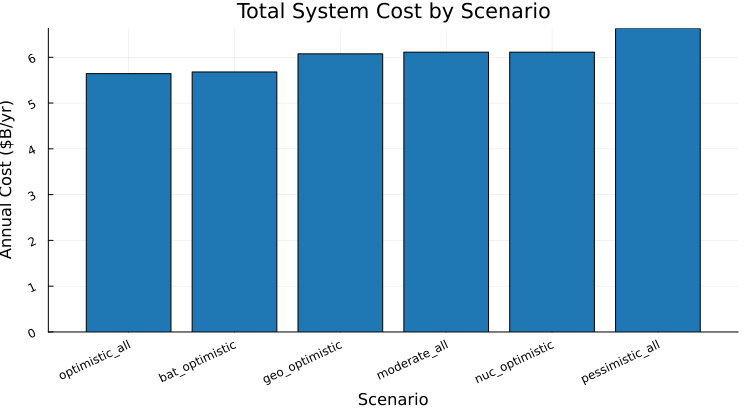

In [24]:
# ── 7.1 Total system cost by scenario ────────────────────────────────────────
sort!(all_cost, :Total_B)
println("=== Total System Cost (\$B/yr) ===")
show(all_cost[:, [:Scenario, :Total_B, :FixedGen_B, :FixedStor_B, :Variable_B, :NSE_B]], allrows=true)

bar(all_cost.Scenario, all_cost.Total_B,
    xlabel="Scenario", ylabel="Annual Cost (\$B/yr)",
    title="Total System Cost by Scenario",
    legend=false, color=palette(:tab10)[1], rotation=25,
    bottom_margin=8Plots.mm, size=(750,420))

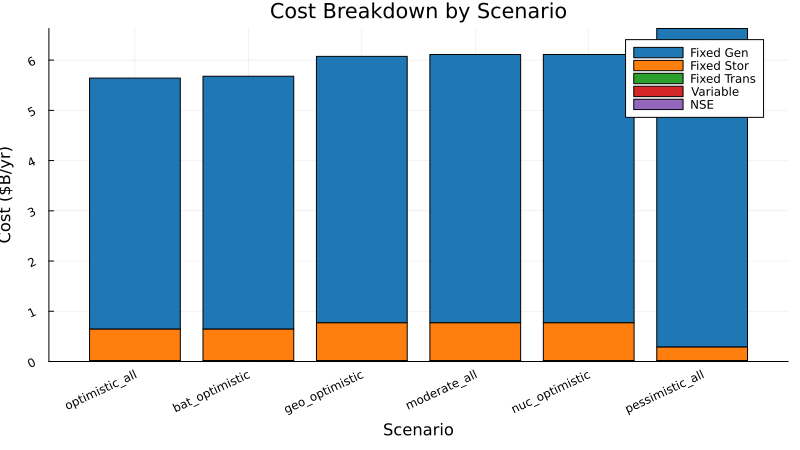

In [25]:
# ── 7.2 Stacked cost breakdown ────────────────────────────────────────────────
cost_mat   = Matrix(all_cost[:, [:FixedGen_B, :FixedStor_B, :FixedTrans_B, :Variable_B, :NSE_B]])
cost_labels = ["Fixed Gen" "Fixed Stor" "Fixed Trans" "Variable" "NSE"]
scen_order  = all_cost.Scenario

groupedbar(cost_mat, bar_position=:stack,
    label=cost_labels,
    xticks=(1:length(scen_order), scen_order),
    xlabel="Scenario", ylabel="Cost (\$B/yr)",
    title="Cost Breakdown by Scenario",
    rotation=25, bottom_margin=8Plots.mm, size=(800,450),
    palette=:tab10, legend=:topright)

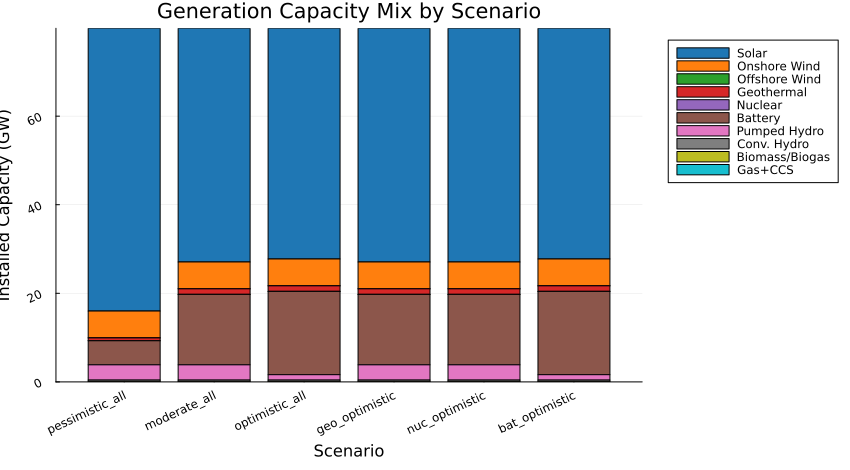

In [26]:
# ── 7.3 Capacity mix (GW) by scenario and technology family ──────────────────
cap_mix = combine(groupby(all_gen, [:Scenario, :Family]),
                  :Total_MW => (x -> sum(x)/1e3) => :GW)

families_ordered = ["Solar","Onshore Wind","Offshore Wind","Geothermal","Nuclear",
                    "Battery","Pumped Hydro","Conv. Hydro","Biomass/Biogas","Gas+CCS","Other"]
families_present = intersect(families_ordered, unique(cap_mix.Family))
scens = active_scenarios  # preserve input order

cap_mat = zeros(length(scens), length(families_present))
for (i,sc) in enumerate(scens), (j,fam) in enumerate(families_present)
    rows = cap_mix[(cap_mix.Scenario .== sc) .& (cap_mix.Family .== fam), :]
    cap_mat[i,j] = nrow(rows) > 0 ? rows.GW[1] : 0.0
end

groupedbar(cap_mat, bar_position=:stack,
    label=reshape(families_present, 1, :),
    xticks=(1:length(scens), scens),
    xlabel="Scenario", ylabel="Installed Capacity (GW)",
    title="Generation Capacity Mix by Scenario",
    rotation=25, bottom_margin=8Plots.mm, size=(850,470),
    palette=:tab10, legend=:outertopright)

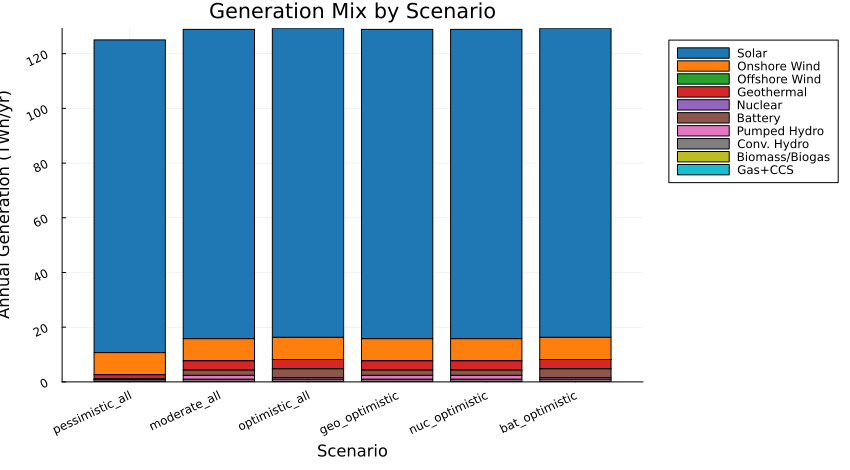

In [27]:
# ── 7.4 Generation mix (TWh/yr) ──────────────────────────────────────────────
gen_mix = combine(groupby(all_gen, [:Scenario, :Family]),
                  :GWh_yr => sum => :TWh)

gen_mat = zeros(length(scens), length(families_present))
for (i,sc) in enumerate(scens), (j,fam) in enumerate(families_present)
    rows = gen_mix[(gen_mix.Scenario .== sc) .& (gen_mix.Family .== fam), :]
    gen_mat[i,j] = nrow(rows) > 0 ? rows.TWh[1] / 1e3 : 0.0  # GWh → TWh
end

groupedbar(gen_mat, bar_position=:stack,
    label=reshape(families_present, 1, :),
    xticks=(1:length(scens), scens),
    xlabel="Scenario", ylabel="Annual Generation (TWh/yr)",
    title="Generation Mix by Scenario",
    rotation=25, bottom_margin=8Plots.mm, size=(850,470),
    palette=:tab10, legend=:outertopright)

In [28]:
# ── 7.5 Focal technologies: geothermal, nuclear, battery ─────────────────────
focus = all_gen[in.(all_gen.Family, Ref(["Geothermal","Nuclear","Battery"])), :]
focus_cap = combine(groupby(focus, [:Scenario, :Family]),
    :Total_MW => (x -> sum(x)/1e3) => :GW,
    :New_MW   => (x -> sum(x)/1e3) => :New_GW)

println("\n=== Focal Technology Installed Capacity (GW) ===")
show(sort(focus_cap, [:Family, :Scenario]), allrows=true)

groupedbar(
    [focus_cap[focus_cap.Family .== fam, :GW] for fam in ["Geothermal","Nuclear","Battery"]],
    label=["Geothermal" "Nuclear" "Battery"],
    xticks=(1:length(scens), scens),
    xlabel="Scenario", ylabel="Total Installed Capacity (GW)",
    title="Focal Technology Capacity by Scenario",
    rotation=25, bottom_margin=8Plots.mm, size=(750,420),
    palette=[:darkorange, :steelblue, :forestgreen])


=== Focal Technology Installed Capacity (GW) ===
18×4 DataFrame
 Row │ Scenario         Family      GW        New_GW   
     │ String           String      Float64   Float64  
─────┼─────────────────────────────────────────────────
   1 │ bat_optimistic   Battery     18.8228   18.8228
   2 │ geo_optimistic   Battery     15.9043   15.9043
   3 │ moderate_all     Battery     15.9043   15.9043
   4 │ nuc_optimistic   Battery     15.9043   15.9043
   5 │ optimistic_all   Battery     18.8228   18.8228
   6 │ pessimistic_all  Battery      5.43299   5.43299
   7 │ bat_optimistic   Geothermal   1.25104   0.0
   8 │ geo_optimistic   Geothermal   1.25104   0.0
   9 │ moderate_all     Geothermal   1.25104   0.0
  10 │ nuc_optimistic   Geothermal   1.25104   0.0
  11 │ optimistic_all   Geothermal   1.25104   0.0
  12 │ pessimistic_all  Geothermal   0.64287   0.0
  13 │ bat_optimistic   Nuclear      0.0      -0.0
  14 │ geo_optimistic   Nuclear      0.0      -0.0
  15 │ moderate_all     Nuclear   

LoadError: BoundsError: attempt to access Tuple{Int64} at index [2]

In [ ]:
# ── 7.6 EGS adoption vs. cost reduction (Ricks & Jenkins 2025 framing) ──────
geo_scens = all_cost[startswith.(all_cost.Scenario, "geo_") .|
                     all_cost.Scenario .== "moderate_all", :]
geo_cap   = combine(groupby(all_gen[all_gen.Family .== "Geothermal", :], :Scenario),
                    :Total_MW => (x -> sum(x)/1e3) => :Geo_GW)
geo_df = innerjoin(geo_scens[:, [:Scenario, :Total_B, :Geo_mult]], geo_cap, on=:Scenario)

if nrow(geo_df) > 0
    scatter(1 .- geo_df.Geo_mult, geo_df.Geo_GW,
        xlabel="EGS Cost Reduction vs. Dataset Baseline",
        ylabel="Total Geothermal Installed (GW)",
        title="EGS Adoption vs. Cost Reduction\n(Ricks & Jenkins 2025 framing)",
        series_annotations=Plots.text.(geo_df.Scenario, :bottom, 8),
        legend=false, markersize=9, color=:darkorange,
        xlims=(-0.05, 0.80), ylims=(0, nothing), size=(600,420))
    hline!([0], linestyle=:dash, color=:gray, label="")
end

LoadError: MethodError: no method matching |(::Bool, ::String)
The function `|` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  |(::Any, ::Any, [91m::Any[39m, [91m::Any...[39m)
[0m[90m   @[39m [90mBase[39m [90m[4moperators.jl:642[24m[39m
[0m  |(::Bool, [91m::Missing[39m)
[0m[90m   @[39m [90mBase[39m [90m[4mmissing.jl:165[24m[39m
[0m  |(::Bool, [91m::Bool[39m)
[0m[90m   @[39m [90mBase[39m [90m[4mbool.jl:41[24m[39m
[0m  ...


In [ ]:
# ── 7.7 New capacity additions ───────────────────────────────────────────────
new_builds = all_gen[all_gen.New_MW .> 0.5, :]
new_agg = combine(groupby(new_builds, [:Scenario, :Family]),
                  :New_MW => (x -> sum(x)/1e3) => :New_GW)
sort!(new_agg, [:Scenario, :Family])
println("\n=== New Capacity Built (GW) ===")
show(new_agg, allrows=true)


=== New Capacity Built (GW) ===
12×3 DataFrame
 Row │ Scenario         Family   New_GW   
     │ String           String   Float64  
─────┼────────────────────────────────────
   1 │ bat_optimistic   Battery  18.8228
   2 │ bat_optimistic   Solar    39.7703
   3 │ geo_optimistic   Battery  15.9043
   4 │ geo_optimistic   Solar    40.4483
   5 │ moderate_all     Battery  15.9043
   6 │ moderate_all     Solar    40.4483
   7 │ nuc_optimistic   Battery  15.9043
   8 │ nuc_optimistic   Solar    40.4483
   9 │ optimistic_all   Battery  18.8228
  10 │ optimistic_all   Solar    39.7703
  11 │ pessimistic_all  Battery   5.43299
  12 │ pessimistic_all  Solar    51.5278

In [ ]:
# ── 7.8 Early retirements ────────────────────────────────────────────────────
rets = all_gen[all_gen.Retired_MW .> 0.5, :]
if nrow(rets) > 0
    ret_agg = combine(groupby(rets, [:Scenario, :Family]),
                      :Retired_MW => (x -> sum(x)/1e3) => :Retired_GW)
    sort!(ret_agg, [:Scenario, :Family])
    println("\n=== Early Retirements (GW) ===")
    show(ret_agg, allrows=true)
else
    println("No early retirements in this pilot run.")
end


=== Early Retirements (GW) ===
15×3 DataFrame
 Row │ Scenario         Family          Retired_GW 
     │ String           String          Float64    
─────┼─────────────────────────────────────────────
   1 │ bat_optimistic   Biomass/Biogas     0.13836
   2 │ bat_optimistic   Conv. Hydro        8.00344
   3 │ bat_optimistic   Pumped Hydro       2.24056
   4 │ geo_optimistic   Biomass/Biogas     0.13836
   5 │ geo_optimistic   Conv. Hydro        8.00344
   6 │ moderate_all     Biomass/Biogas     0.13836
   7 │ moderate_all     Conv. Hydro        8.00344
   8 │ nuc_optimistic   Biomass/Biogas     0.13836
   9 │ nuc_optimistic   Conv. Hydro        8.00344
  10 │ optimistic_all   Biomass/Biogas     0.13836
  11 │ optimistic_all   Conv. Hydro        8.00344
  12 │ optimistic_all   Pumped Hydro       2.24056
  13 │ pessimistic_all  Biomass/Biogas     0.13836
  14 │ pessimistic_all  Conv. Hydro        8.00344
  15 │ pessimistic_all  Geothermal         0.60817

In [ ]:
# ── 7.9 Storage portfolio ────────────────────────────────────────────────────
stor_agg = combine(groupby(all_stor, [:Scenario, :Resource, :Zone]),
    :Total_MW  => sum => :MW,
    :Total_MWh => sum => :MWh,
    :Duration_hr => mean => :Avg_Duration)
println("\n=== Storage Portfolio ===")
show(sort(stor_agg[stor_agg.MW .> 0.5, :], [:Scenario, :Resource]), allrows=true)


=== Storage Portfolio ===
23×6 DataFrame
 Row │ Scenario         Resource                      Zone      MW         MWh ⋯
     │ String           String31                      String15  Float64    Flo ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ bat_optimistic   battery                       CA_N       8012.92   718 ⋯
   2 │ bat_optimistic   battery                       CA_S      10809.9    724
   3 │ bat_optimistic   hydroelectric_pumped_storage  CA_N        617.242  284
   4 │ bat_optimistic   hydroelectric_pumped_storage  CA_S        598.149  264
   5 │ geo_optimistic   battery                       CA_N       6801.79   470 ⋯
   6 │ geo_optimistic   battery                       CA_S       9102.5    648
   7 │ geo_optimistic   hydroelectric_pumped_storage  CA_N       1790.95   284
   8 │ geo_optimistic   hydroelectric_pumped_storage  CA_S       1665.0    264
   9 │ moderate_all     battery                       CA_N       6801.79   470 

In [ ]:
# ── 7.10 NSE check ───────────────────────────────────────────────────────────
nse_check = combine(groupby(all_nse, :Scenario), :NSE_MWh => sum => :Total_NSE_MWh)
println("\n=== Non-Served Energy (MWh/yr) ===")
show(nse_check, allrows=true)


=== Non-Served Energy (MWh/yr) ===
6×2 DataFrame
 Row │ Scenario         Total_NSE_MWh 
     │ String           Float64       
─────┼────────────────────────────────
   1 │ pessimistic_all            0.0
   2 │ moderate_all               0.0
   3 │ optimistic_all             0.0
   4 │ geo_optimistic             0.0
   5 │ nuc_optimistic             0.0
   6 │ bat_optimistic             0.0

## 8. Scaling to Full Run

To run the full 16-week, 6-zone model with all 15 scenarios:

```julia
# Section 3
ACTIVE_ZONES    = collect(1:6)          # all 6 zones
ACTIVE_PERIODS  = collect(1:16)         # all 16 representative weeks
INCLUDE_FLEX_LOAD = true                # include EV load shifting

# Section 4
active_scenarios = collect(keys(cost_scenarios))   # all 15 scenarios
```

**High-electrification case**: change `data_path = "data_high_elec/"` (same file structure).

**Solver guidance for full run (6 zones × 2688 hours × 159 generators):**

| Solver | Estimated time/scenario | Notes |
|---|---|---|
| HiGHS (free) | 30–90 min | Set `set_optimizer_attribute(m, "time_limit", 7200.0)` |
| Gurobi (licensed) | 5–20 min | Replace `HiGHS.Optimizer` with `Gurobi.Optimizer` |
| CPLEX (licensed) | 5–15 min | Replace with `CPLEX.Optimizer` |

**If runtime is prohibitive with HiGHS**: HiGHS has a `simplex` and an `ipm` (interior point)
method. For large LPs, try `set_optimizer_attribute(m, "solver", "ipm")` which can be faster
on highly-structured problems like this one.

**Approximate model size (full run):** ~2.5M variables, ~4M constraints.  
The LP remains tractable on a modern workstation; integer commitment variables would require Gurobi/CPLEX.
